# Labo 1 — Apprentissage machine : reconnaître la condition d'un essai à partir de son EEG

**PSY2007D, édition 2026.** Les notebooks 09 et 10 comparent des **moyennes** : l'ERP ou la puissance moyenne de chaque condition, chez chaque
participant. Ici, on pose une autre question : à partir de l'EEG d'**un seul essai**, un modèle peut-il dire dans quelle condition il a été
enregistré ? C'est un **classifieur** : on l'entraîne sur des essais dont on connaît la condition, puis on le teste sur des essais qu'il n'a
jamais vus. Le notebook suit six étapes :

1. **les attributs** : résumer chaque essai par quelques nombres (les ERP du notebook 09 et les bandes du notebook 10) ;
2. **un modèle par participant**, évalué par validation croisée ;
3. **d'où vient l'information** : les ERP, les bandes, ou les deux ?
4. **quand elle apparaît** : un modèle à chaque instant de l'époque ;
5. **mieux que le hasard ?** le test de permutation ;
6. **généraliser à une nouvelle personne** : entraîner sur les autres participants, tester sur celui qui reste.

**Une mise en garde, dès le départ.** Un modèle apprend tout ce qui distingue les deux conditions, pas seulement ce qui nous intéresse. Si
une condition est plus bruitée, il peut reconnaître le bruit. Une bonne précision ne dit pas *pourquoi* le modèle réussit : c'est à vous de
le vérifier.

**Comment utiliser ce notebook.** Exécutez les cellules dans l'ordre (Maj + Entrée). **Bloc Type 1** : lisez et exécutez. **Bloc Type 2** :
changez un paramètre marqué `# modifiable` puis relancez la cellule et toutes celles qui suivent (menu *Exécuter* → *Exécuter la cellule
sélectionnée et toutes celles en dessous*). **Bloc Type 3** : facultatif. Vos choix principaux sont réunis dans la cellule 0.4. Le calcul
complet prend quelques minutes.

## 0. Mise en place (Bloc Type 1)

La cellule 0.1 télécharge les données du cours (855 Mo) depuis Google Drive et les décompresse dans `tasks/brainwalk/`, à côté du
notebook. Elle ne le fait qu'une fois : si les données sont déjà là, elle passe. Les quatre notebooks du labo (01, 09, 10 et 11) utilisent
ce même dossier. Il n'y a rien à télécharger à la main.

- **Sur votre ordinateur** : ouvrez le notebook depuis le dossier du dépôt cloné (`git clone`). Les données arrivent dans `tasks/brainwalk/`
  du dépôt, que Git ignore.
- **Dans Google Colab** : la cellule installe aussi MNE. Colab efface ses fichiers à la fin de la session : la cellule retélécharge alors
  les données (une ou deux minutes).

In [1]:
# ---- 0.1 Les données : téléchargées une seule fois, dans tasks/brainwalk à côté du notebook ---------------------------------------
import sys                                                   # pour savoir si le notebook tourne dans Google Colab
import zipfile                                               # pour décompresser les données
import urllib.request                                        # pour télécharger les données
from pathlib import Path                                     # pour écrire des chemins de fichiers
import hashlib                                               # pour reconnaître la version des données

EN_COLAB = 'google.colab' in sys.modules                     # True dans Google Colab, False sur votre ordinateur
if EN_COLAB:
    # Colab n'a pas MNE : on l'installe (environ une minute)
    !pip install -q mne
DOSSIER = Path('tasks/brainwalk')                            # ne pas modifier : les données, dans tasks/ à côté du notebook
ID_DRIVE = '19nnPiRuypz5fCPISybipdjxeop2EA_P8'               # ne pas modifier : le fichier labo1_donnees_2026.zip sur Google Drive
EMPREINTE = '123a0b4bc32ecf49'                               # ne pas modifier : l'empreinte de manifest.json dans cette version des données


def donnees_a_jour():
    """True si DOSSIER contient cette version des données (l'empreinte de son fichier manifest.json)."""
    manifeste = DOSSIER / 'manifest.json'
    return manifeste.exists() and hashlib.sha256(manifeste.read_bytes()).hexdigest()[:16] == EMPREINTE


def progression(blocs, taille_bloc, total):
    """Affiche l'avancement du téléchargement, tous les 10 %."""
    if total > 0 and blocs * taille_bloc * 10 // total > (blocs - 1) * taille_bloc * 10 // total:
        print(f'  {min(100, 100 * blocs * taille_bloc // total)} %')


if not donnees_a_jour():                                     # absentes, ou une ancienne version : on les télécharge (855 Mo)
    archive = DOSSIER.parent / 'labo1_donnees_2026.zip'
    archive.parent.mkdir(parents=True, exist_ok=True)
    print('Téléchargement des données depuis Google Drive (855 Mo, quelques minutes) :')
    urllib.request.urlretrieve(f'https://drive.usercontent.google.com/download?id={ID_DRIVE}&export=download&confirm=t', archive, progression)
    if not zipfile.is_zipfile(archive):                      # Google Drive a renvoyé une page web au lieu du fichier
        archive.unlink()
        raise RuntimeError('Google Drive n\'a pas envoyé les données (trop de téléchargements aujourd\'hui ?). Réessayez plus tard.')
    with zipfile.ZipFile(archive) as z:
        z.extractall(DOSSIER.parent)                         # crée tasks/brainwalk/
    archive.unlink()                                         # le zip ne sert plus
print('Données :', DOSSIER, '(prêtes)' if donnees_a_jour() else '(INTROUVABLES : relancez cette cellule)')

Données : tasks\brainwalk (prêtes)


In [2]:
# ---- 0.2 Les bibliothèques -------------------------------------------------------------------------------------------------------
import numpy as np                                           # calcul sur des tableaux de nombres
import pandas as pd                                          # tableaux de données (comme un tableur)
import matplotlib.pyplot as plt                              # figures
import mne                                                   # l'EEG
import warnings                                              # pour masquer un avertissement attendu (section 1.2)
from scipy import stats                                      # les tests statistiques
from sklearn.pipeline import make_pipeline                   # enchaîner une standardisation et un modèle
from sklearn.preprocessing import StandardScaler             # mettre chaque attribut à la même échelle
from sklearn.impute import SimpleImputer                     # remplir une valeur manquante (une électrode reconstruite) par une moyenne
from sklearn.linear_model import LogisticRegression          # le classifieur principal
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis   # d'autres classifieurs (section 7)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, LeaveOneGroupOut, cross_val_score, cross_val_predict,
                                     permutation_test_score)  # la validation croisée et le test de permutation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mne.set_log_level('ERROR')                                   # MNE n'affiche que les erreurs
warnings.filterwarnings('ignore', message='Skipping features without any observed values')   # une électrode jamais mesurée chez un
                                                             # participant n'a pas de valeur : SimpleImputer la laisse de côté
print('MNE', mne.__version__)

MNE 1.13.2


### 0.3 Les données (Bloc Type 1)

Le notebook utilise deux des fichiers fournis, pour les mêmes essais (réponse correcte, temps de réaction normal, EEG sans artefact) :
- **les époques du mot** (`pretraite/sub-PXXX_epo.fif`, de -0,2 à 1,0 s, celles du notebook 09) : pour les ERP ;
- **les époques longues** (`pretraite/longues/sub-PXXX_longues_epo.fif`, de -1,0 à 1,5 s, celles du notebook 10) : pour la puissance des
  bandes. Elles ont un peu moins d'essais : on ne garde que les essais présents dans les deux fichiers.

**Les électrodes reconstruites.** Dans les deux fichiers, la colonne `reconstruites` des métadonnées donne les électrodes qui n'ont pas
été mesurées dans l'essai, mais reconstruites à partir de leurs voisines. Une électrode reconstruite n'est pas une mesure : elle suit à
peu près l'ERP moyen de ses voisines, mais presque pas leur signal essai par essai (notebook 01, 11.10). Pour un modèle qui travaille
essai par essai, ses valeurs sont donc des valeurs manquantes (section 1).

In [3]:
# ---- 0.3 Charger les deux sortes d'époques ---------------------------------------------------------------------------------------
epochs_mots, epochs_longues = {}, {}                         # participant -> ses époques
for fichier in sorted((DOSSIER / 'pretraite').glob('sub-*_epo.fif')):
    participant = fichier.name.split('_')[0][4:]             # 'sub-P003_epo.fif' -> 'P003'
    longues = DOSSIER / 'pretraite' / 'longues' / f'sub-{participant}_longues_epo.fif'
    if not longues.exists():
        raise ValueError('Les époques longues (pretraite/longues/) sont introuvables : relancez la cellule 0.1, elle télécharge la dernière version des données')
    epochs_mots[participant] = mne.read_epochs(fichier, preload=True)
    epochs_longues[participant] = mne.read_epochs(longues, preload=True)
print(f'{len(epochs_mots)} participants : {", ".join(epochs_mots)}')

10 participants : P002, P003, P004, P005, P006, P007, P008, P009, P010, P012


### 0.4 Votre question et vos choix (Bloc Type 2)

**La cible** est ce que le modèle doit reconnaître :

| `CIBLE` | Les deux classes | Ce qu'on demande au modèle |
|---|---|---|
| `'posture'` | assis / en marche | reconnaître la posture d'un essai |
| `'lexicalite'` | mot / pseudo-mot | reconnaître si l'essai montrait un mot du français |
| `'frequence'` | mot fréquent (HF) / mot rare (LF) | reconnaître la fréquence du mot (les pseudo-mots sont laissés de côté) |

Avant d'exécuter, **écrivez votre prédiction** : quelle cible sera la plus facile à reconnaître ? Pourquoi ?

In [4]:
# ---- 0.4 Vos choix ---------------------------------------------------------------------------------------------------------------
CIBLE = 'posture'            # modifiable : 'posture', 'lexicalite' ou 'frequence'
POSTURE = 'les deux'         # modifiable, pour 'lexicalite' et 'frequence' : 'les deux', 'assis' ou 'marche'
ATTRIBUTS = 'les deux'       # modifiable : 'erp', 'bandes' ou 'les deux' (section 1)
PARTICIPANT_EXEMPLE = 'P003' # modifiable : le participant des figures F1, F3 et F6
N_PLIS = 5                   # modifiable : le nombre de plis de la validation croisée (section 2)
GRAINE = 42                  # ne pas modifier : la graine du hasard, pour retrouver les mêmes plis à chaque exécution

CLASSES = {'posture': ('posture', 'assis', 'marche'), 'lexicalite': ('lexicalite', 'mot', 'pseudo-mot'),
           'frequence': ('type', 'HF', 'LF')}               # ne pas modifier : (colonne des métadonnées, classe A, classe B)
COLONNE, CLASSE_A, CLASSE_B = CLASSES[CIBLE]
bilan = {}                                                   # tous les tests du notebook, pour la synthèse (section 8)
print(f'Cible « {CIBLE} » : {CLASSE_A} contre {CLASSE_B}' + (f', essais {POSTURE}' if CIBLE != 'posture' and POSTURE != 'les deux' else '')
      + f' ; attributs : {ATTRIBUTS}')

Cible « posture » : assis contre marche ; attributs : les deux


## 1. Les attributs de chaque essai (Bloc Type 1)

Un essai contient 19 électrodes x 361 instants : plus de 6 800 nombres, pour quelques centaines d'essais par participant. Avec autant de
nombres et si peu d'essais, un modèle apprend facilement le bruit des essais d'entraînement. On résume donc chaque essai par des
**attributs** (*features*) choisis à l'avance :
- **ERP** : l'amplitude moyenne de chaque électrode dans les trois fenêtres du notebook 09 (P2 : 180 à 250 ms, N400 : 300 à 500 ms, LPC :
  500 à 800 ms après le mot), soit 3 x 19 = 57 attributs ;
- **bandes** : la puissance (en dB) de chaque électrode dans les trois bandes du notebook 10 (thêta, alpha, bêta), de 0 à 1 s après le mot,
  soit encore 57 attributs.

Chaque ligne du tableau est un essai ; chaque colonne, un attribut. Un attribut d'une électrode reconstruite dans l'essai n'a pas de valeur
(NaN) : le modèle la remplace par la moyenne de cet attribut dans ses essais d'entraînement (cellule 1.2), sans rien apprendre des
voisines. Près d'un tiers des valeurs manquent ainsi (sortie de 1.1).

In [5]:
# ---- 1.1 Les attributs de chaque essai -------------------------------------------------------------------------------------------
FENETRES_ERP = {'P2': (0.180, 0.250), 'N400': (0.300, 0.500), 'LPC': (0.500, 0.800)}   # ne pas modifier : les fenêtres du notebook 09 (s)
BANDES = {'thêta': (4, 7), 'alpha': (8, 12), 'bêta': (13, 25)}   # ne pas modifier : les bandes du notebook 10 (Hz)
FENETRE_BANDES = (0.0, 1.0)  # modifiable : la période après le mot où l'on mesure la puissance des bandes (s)
tables = []


def mesurees(ep):
    """Essais x électrodes : True là où l'électrode a été mesurée dans l'essai (pas reconstruite : colonne reconstruites des métadonnées)."""
    return np.array([[c not in str(r).split() for c in ep.ch_names] for r in ep.metadata['reconstruites']])


for participant, mots in epochs_mots.items():
    colonnes = {}
    for nom, (t0, t1) in FENETRES_ERP.items():
        moyennes = mots.get_data(tmin=t0, tmax=t1, units='uV').mean(axis=2)   # essais x électrodes : l'amplitude moyenne dans la fenêtre
        moyennes = np.where(mesurees(mots), moyennes, np.nan)  # une électrode reconstruite dans l'essai n'a pas de valeur (NaN)
        for k, c in enumerate(mots.ch_names):
            colonnes[f'erp {nom} {c}'] = moyennes[:, k]
    table = pd.concat([mots.metadata[['participant', 'posture', 'type', 'lexicalite', 'essai', 'tr_ms']].reset_index(drop=True),
                       pd.DataFrame(colonnes)], axis=1)
    longues = epochs_longues[participant]
    psd = longues.compute_psd(method='welch', tmin=FENETRE_BANDES[0], tmax=FENETRE_BANDES[1], fmin=3.0, fmax=25.0, n_fft=100, n_per_seg=100)
    spectre = psd.get_data() * 1e12                          # essais x électrodes x fréquences (µV²/Hz)
    colonnes = {}
    for nom, (f0, f1) in BANDES.items():
        db = 10 * np.log10(spectre[:, :, (psd.freqs >= f0) & (psd.freqs <= f1)].mean(axis=2))   # essais x électrodes (dB)
        db = np.where(mesurees(longues), db, np.nan)          # pas de valeur pour une électrode reconstruite
        for k, c in enumerate(longues.ch_names):
            colonnes[f'bande {nom} {c}'] = db[:, k]
    table_b = pd.concat([longues.metadata[['posture', 'essai']].reset_index(drop=True), pd.DataFrame(colonnes)], axis=1)
    tables.append(table.merge(table_b, on=['posture', 'essai']))   # les essais présents dans les deux fichiers
attributs = pd.concat(tables, ignore_index=True)
COLONNES = {'erp': [c for c in attributs if c.startswith('erp ')], 'bandes': [c for c in attributs if c.startswith('bande ')]}
COLONNES['les deux'] = COLONNES['erp'] + COLONNES['bandes']
print(f'{len(attributs)} essais, {len(COLONNES["erp"])} attributs ERP et {len(COLONNES["bandes"])} attributs de bande ; '
      f'{100 * attributs[COLONNES["les deux"]].isna().to_numpy().mean():.0f} % des valeurs manquent (électrodes reconstruites)')
attributs.groupby(['participant', 'posture']).size().unstack(fill_value=0)   # le nombre d'essais gardés

4536 essais, 57 attributs ERP et 57 attributs de bande ; 31 % des valeurs manquent (électrodes reconstruites)


posture,assis,marche
participant,,
P002,317,264
P003,349,201
P004,285,83
P005,0,159
P006,245,0
P007,318,72
P008,330,154
P009,334,189
P010,348,177


In [6]:
# ---- 1.2 Les essais de votre cible, et un nouveau modèle à chaque usage ----------------------------------------------------------


def essais_de(participant):
    """Les essais d'un participant pour votre cible : ceux de la posture choisie et, pour la fréquence, les seuls mots."""
    t = attributs[attributs['participant'] == participant]
    if CIBLE != 'posture' and POSTURE != 'les deux':
        t = t[t['posture'] == POSTURE]
    return t[t[COLONNE].isin([CLASSE_A, CLASSE_B])]


def nouveau_modele():
    """Une valeur manquante (une électrode reconstruite) remplacée par la moyenne de l'attribut dans les essais d'entraînement, une
    standardisation (chaque attribut ramené à une moyenne de 0 et un écart-type de 1, apprise elle aussi sur les essais d'entraînement), puis
    une régression logistique. Les poids des classes compensent leurs nombres d'essais différents."""
    return make_pipeline(SimpleImputer(strategy='mean'), StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=2000))


t = essais_de(PARTICIPANT_EXEMPLE)
print(f'{PARTICIPANT_EXEMPLE} : {int((t[COLONNE] == CLASSE_A).sum())} essais {CLASSE_A}, {int((t[COLONNE] == CLASSE_B).sum())} essais {CLASSE_B}')

P003 : 349 essais assis, 201 essais marche


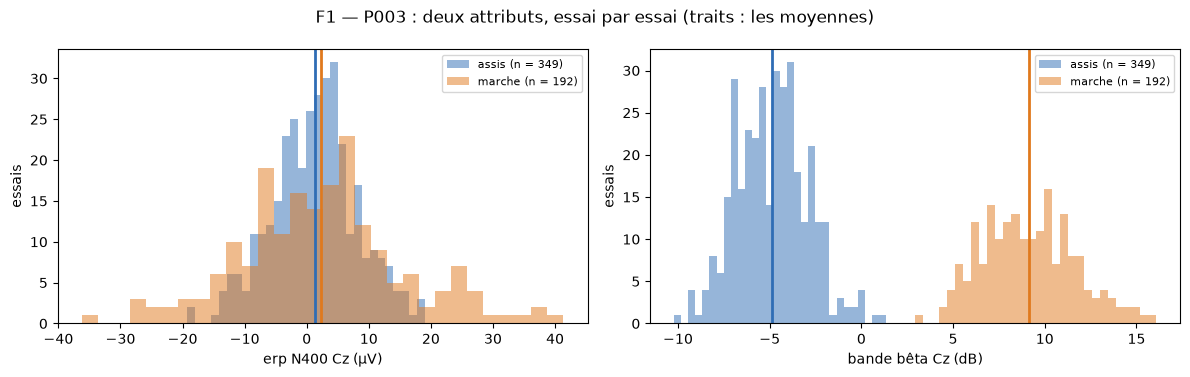

In [7]:
# ---- F1 : deux attributs de votre participant, pour chaque classe ----------------------------------------------------------------
exemples = ['erp N400 Cz', 'bande bêta Cz']                 # modifiable : deux colonnes du tableau d'attributs
t = essais_de(PARTICIPANT_EXEMPLE)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, colonne in zip(axes, exemples):
    for classe, couleur in ((CLASSE_A, '#2f6db5'), (CLASSE_B, '#e0791d')):
        valeurs = t.loc[t[COLONNE] == classe, colonne].dropna()   # les essais où l'électrode est mesurée
        ax.hist(valeurs, bins=30, color=couleur, alpha=0.5, label=f'{classe} (n = {len(valeurs)})')
        ax.axvline(valeurs.mean(), color=couleur, lw=2)      # la moyenne de la classe
    ax.set_xlabel(colonne + (' (µV)' if colonne.startswith('erp') else ' (dB)'))
    ax.set_ylabel('essais')
    ax.legend(fontsize=8)
fig.suptitle(f'F1 — {PARTICIPANT_EXEMPLE} : deux attributs, essai par essai (traits : les moyennes)')
plt.tight_layout()
plt.show()

**Que regarder ? (F1)** Chaque histogramme montre un attribut pour tous les essais de P003, une couleur par classe. Avec la cible de
départ (la posture), l'ERP de la N400 à Cz se chevauche presque entièrement entre assis et en marche : un essai seul n'en dit presque
rien. La puissance du bêta à Cz, elle, sépare les deux postures presque sans erreur : elle est plus haute d'environ 14 dB en marche. C'est
le bruit de la marche vu dans le notebook 10 (F1), pas un rythme du cerveau.

Changez `CIBLE` (cellule 0.4) : pour le mot contre le pseudo-mot, les deux classes se chevauchent pour les deux attributs, et la puissance
du bêta a deux bosses, qui sont les essais assis et les essais en marche.

## 2. Un modèle par participant (Bloc Type 1)

**Le modèle.** Une **régression logistique** combine les attributs avec un poids chacun et donne, pour un essai, la probabilité qu'il
appartienne à la classe B. Avant, chaque attribut est **standardisé**, pour que les µV et les dB pèsent de la même façon.

**La validation croisée.** Tester un modèle sur les essais qui ont servi à l'entraîner ne dit rien : il pourrait les avoir appris par cœur.
On coupe donc les essais d'un participant en 5 **plis** (avec la même proportion de chaque classe dans chacun) ; on entraîne sur 4 plis et
on teste sur le cinquième, cinq fois, puis on fait la moyenne. Chaque essai est testé une fois, par un modèle qui ne l'a jamais vu.

**La précision équilibrée.** C'est la moyenne de la précision dans chaque classe. Elle vaut 0,5 au hasard, même si une classe a plus d'essais
que l'autre (une précision ordinaire de 0,6 serait facile à atteindre en répondant toujours « la classe la plus nombreuse », si elle a 60 %
des essais).

In [8]:
# ---- 2.1 La précision équilibrée de chaque participant ---------------------------------------------------------------------------
plis = StratifiedKFold(n_splits=N_PLIS, shuffle=True, random_state=GRAINE)   # les plis : la même proportion des classes dans chacun
lignes = []
for participant in epochs_mots:
    t = essais_de(participant)
    y = (t[COLONNE] == CLASSE_B).to_numpy(int)               # 0 : classe A, 1 : classe B
    if min((y == 0).sum(), (y == 1).sum()) < 20:
        print(f'{participant} laissé de côté : {(y == 0).sum()} essais {CLASSE_A}, {(y == 1).sum()} essais {CLASSE_B}')
        continue
    scores = cross_val_score(nouveau_modele(), t[COLONNES[ATTRIBUTS]].to_numpy(), y, cv=plis, scoring='balanced_accuracy')
    lignes.append({'participant': participant, f'essais {CLASSE_A}': int((y == 0).sum()), f'essais {CLASSE_B}': int((y == 1).sum()),
                   'précision équilibrée': scores.mean()})
resultats = pd.DataFrame(lignes).set_index('participant')
t_g, p_g = stats.ttest_1samp(resultats['précision équilibrée'], 0.5)   # le groupe fait-il mieux que le hasard (0,5) ?
print(f'Moyenne du groupe : {resultats["précision équilibrée"].mean():.3f} ; contre 0,5 : t({len(resultats) - 1}) = {t_g:.2f}, p = {p_g:.4f}')
bilan[f'2.1 {CIBLE} ({ATTRIBUTS}) : précision contre 0,5'] = dict(n=len(resultats), moyenne=round(resultats['précision équilibrée'].mean(), 3),
                                                                  t=round(t_g, 2), p=round(p_g, 4))
resultats.round(3)

P005 laissé de côté : 0 essais assis, 159 essais marche
P006 laissé de côté : 245 essais assis, 0 essais marche


Moyenne du groupe : 0.996 ; contre 0,5 : t(7) = 210.00, p = 0.0000


,essais assis,essais marche,précision équilibrée
participant,,,
P002,317,264,0.996
P003,349,201,1.000
P004,285,83,1.000
P007,318,72,0.983
P008,330,154,1.000
P009,334,189,1.000
P010,348,177,0.999
P012,370,341,0.987


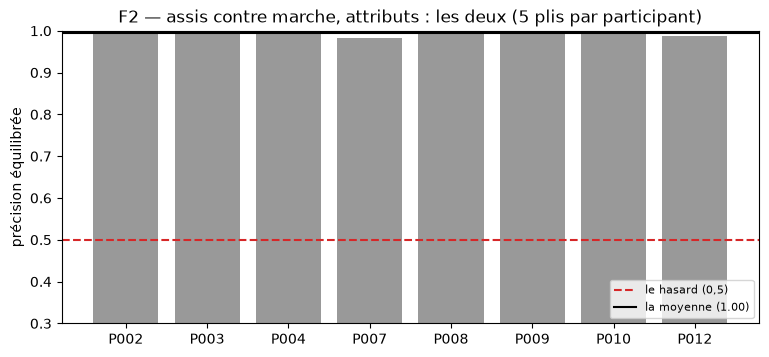

In [9]:
# ---- F2 : la précision équilibrée de chaque participant --------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(resultats.index, resultats['précision équilibrée'], color='0.6')
ax.axhline(0.5, color='C3', ls='--', label='le hasard (0,5)')
ax.axhline(resultats['précision équilibrée'].mean(), color='k', label=f'la moyenne ({resultats["précision équilibrée"].mean():.2f})')
ax.set_ylim(0.3, 1.0)
ax.set_ylabel('précision équilibrée')
ax.set_title(f'F2 — {CLASSE_A} contre {CLASSE_B}, attributs : {ATTRIBUTS} ({N_PLIS} plis par participant)')
ax.legend(loc='lower right', fontsize=8)
plt.show()

**Que regarder ? (F2)** Avec la posture, le modèle reconnaît presque chaque essai (0,996 en moyenne). Ne concluez pas trop vite que
l'EEG « lit » la marche : la section 3 montre d'où vient cette réussite. Avec `CIBLE = 'lexicalite'`, la précision moyenne est de 0,57 :
au-dessus du hasard chez les 10 participants, mais loin de 1, parce qu'un essai seul est très bruité. Avec `'frequence'`, elle reste au
niveau du hasard (0,48).

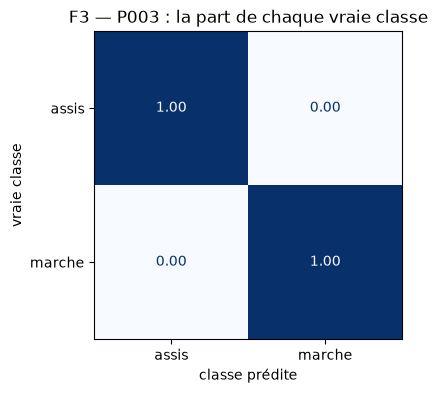

In [10]:
# ---- F3 : la matrice de confusion de votre participant ---------------------------------------------------------------------------
t = essais_de(PARTICIPANT_EXEMPLE)
y = (t[COLONNE] == CLASSE_B).to_numpy(int)
prediction = cross_val_predict(nouveau_modele(), t[COLONNES[ATTRIBUTS]].to_numpy(), y, cv=plis)   # la prédiction de chaque essai, quand il était testé
matrice = confusion_matrix(y, prediction, normalize='true')  # chaque ligne : la vraie classe ; chaque colonne : la classe prédite
fig, ax = plt.subplots(figsize=(4.8, 4))
ConfusionMatrixDisplay(matrice, display_labels=[CLASSE_A, CLASSE_B]).plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=False)
ax.set_xlabel('classe prédite')
ax.set_ylabel('vraie classe')
ax.set_title(f'F3 — {PARTICIPANT_EXEMPLE} : la part de chaque vraie classe')
plt.show()

**Que regarder ? (F3)** La diagonale donne la précision dans chaque classe ; la précision équilibrée est leur moyenne. Hors de la diagonale,
les erreurs : un modèle qui se trompe surtout dans une classe confond cette classe avec l'autre, ou répond trop souvent l'autre.

## 3. D'où vient l'information ? (Bloc Type 1)

Une bonne précision ne dit pas ce que le modèle utilise. Deux façons de le savoir :
1. **comparer les attributs** : refaire la section 2 avec les seuls ERP, les seules bandes, puis les deux ;
2. **regarder chaque attribut** : pour chaque électrode et chaque fenêtre ou bande, la différence entre les deux classes, en écarts-types
   (le *d* de Cohen : la différence des moyennes divisée par l'écart-type des essais), moyennée sur les participants. Un attribut dont le d
   est loin de 0 aide le modèle.

In [11]:
# ---- 3.1 La précision avec chaque jeu d'attributs --------------------------------------------------------------------------------
lignes = []
for participant in resultats.index:
    t = essais_de(participant)
    y = (t[COLONNE] == CLASSE_B).to_numpy(int)
    ligne = {'participant': participant}
    for jeu in ('erp', 'bandes', 'les deux'):
        ligne[jeu] = cross_val_score(nouveau_modele(), t[COLONNES[jeu]].to_numpy(), y, cv=plis, scoring='balanced_accuracy').mean()
    lignes.append(ligne)
par_jeu = pd.DataFrame(lignes).set_index('participant')
for jeu in par_jeu:
    t_j, p_j = stats.ttest_1samp(par_jeu[jeu], 0.5)
    print(f'{jeu:8s} : précision moyenne {par_jeu[jeu].mean():.3f} (contre 0,5 : t({len(par_jeu) - 1}) = {t_j:.2f}, p = {p_j:.4f})')
    bilan[f'3.1 {CIBLE}, attributs {jeu} : précision contre 0,5'] = dict(n=len(par_jeu), moyenne=round(par_jeu[jeu].mean(), 3),
                                                                         t=round(t_j, 2), p=round(p_j, 4))
par_jeu.round(3)

erp      : précision moyenne 0.664 (contre 0,5 : t(7) = 8.95, p = 0.0000)
bandes   : précision moyenne 0.996 (contre 0,5 : t(7) = 209.24, p = 0.0000)
les deux : précision moyenne 0.996 (contre 0,5 : t(7) = 210.00, p = 0.0000)


,erp,bandes,les deux
participant,,,
P002,0.646,0.995,0.996
P003,0.727,1.000,1.000
P004,0.669,1.000,1.000
P007,0.640,0.990,0.983
P008,0.563,1.000,1.000
P009,0.723,1.000,1.000
P010,0.679,0.999,0.999
P012,0.669,0.982,0.987


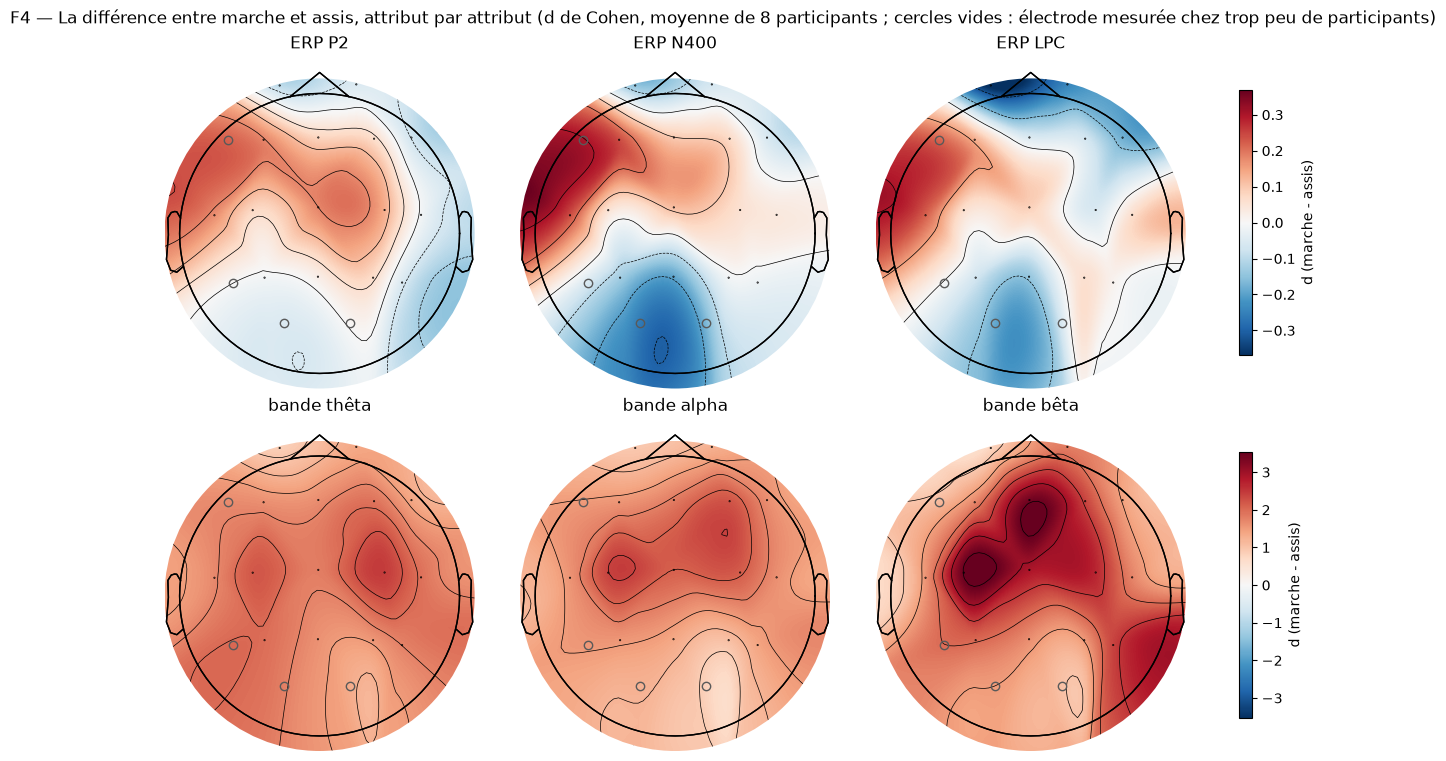

Les 5 attributs dont le d moyen est le plus loin de 0 :
bande bêta C3     3.53
bande bêta Fz     3.44
bande bêta Cz     2.87
bande bêta C4     2.70
bande thêta C4    2.46


In [12]:
# ---- F4 : la différence entre les classes, attribut par attribut (d de Cohen moyen) ----------------------------------------------
from matplotlib.colors import ListedColormap                 # une carte de couleurs transparente, pour les cercles vides
noms_ch = epochs_mots[resultats.index[0]].ch_names
d = []
for participant in resultats.index:
    t = essais_de(participant)
    a_, b_ = t.loc[t[COLONNE] == CLASSE_A, COLONNES['les deux']], t.loc[t[COLONNE] == CLASSE_B, COLONNES['les deux']]
    n_a, n_b = a_.count(), b_.count()                        # les essais où l'attribut est mesuré (les autres sont vides : NaN)
    ecart = np.sqrt((a_.var(ddof=1) * (n_a - 1) + b_.var(ddof=1) * (n_b - 1)) / (n_a + n_b - 2))   # l'écart-type commun
    d.append((b_.mean() - a_.mean()) / ecart)                # le d de Cohen de chaque attribut : B - A (NaN : électrode jamais mesurée)
d = pd.concat(d, axis=1)                                     # attributs x participants
n_mesure = d.notna().sum(axis=1)                             # le nombre de participants qui ont mesuré chaque attribut
d = d.mean(axis=1).where(n_mesure >= max(3, len(resultats) / 2))   # la moyenne des participants, là où assez d'entre eux l'ont mesuré
fig, axes = plt.subplots(2, 3, figsize=(12, 7.5), constrained_layout=True)
for ligne, (famille, noms) in enumerate((('erp', FENETRES_ERP), ('bande', BANDES))):
    limite = max(np.nanmax(np.abs(d[[f'{famille} {n} {c}' for c in noms_ch]])) for n in noms)
    for ax, n in zip(axes[ligne], noms):
        valeurs = d[[f'{famille} {n} {c}' for c in noms_ch]].to_numpy()
        vue = np.isfinite(valeurs)                           # les électrodes mesurées chez assez de participants
        info = epochs_mots[resultats.index[0]].info
        image, _ = mne.viz.plot_topomap(valeurs[vue], mne.pick_info(info, np.flatnonzero(vue)), axes=ax, show=False,
                                        vlim=(-limite, limite), cmap='RdBu_r')
        if not vue.all():                                    # les autres : des cercles vides, sans valeur
            mne.viz.plot_topomap(np.zeros(len(noms_ch)), info, axes=ax, show=False, vlim=(-1, 1), cmap=ListedColormap([(0, 0, 0, 0)]),
                                 contours=0, sensors=False, mask=~vue,
                                 mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='0.35', markersize=6))
        ax.set_title(f'{"ERP" if famille == "erp" else "bande"} {n}')
    fig.colorbar(image, ax=axes[ligne], shrink=0.8, label=f'd ({CLASSE_B} - {CLASSE_A})')
fig.suptitle(f'F4 — La différence entre {CLASSE_B} et {CLASSE_A}, attribut par attribut (d de Cohen, moyenne de {len(resultats)} participants ; '
             f'cercles vides : électrode mesurée chez trop peu de participants)')
plt.show()
print('Les 5 attributs dont le d moyen est le plus loin de 0 :')
print(d.dropna().reindex(d.dropna().abs().sort_values(ascending=False).index).head(5).round(2).to_string())

**Que regarder ? (3.1 et F4)** Pour la posture, les bandes seules donnent 0,996 et les ERP seuls 0,66. Dans F4, les attributs de bande
ont un d de 1 à plus de 3 sur toute la tête, le plus fort au-dessus des régions motrices et du centre (C3, Fz, Cz, C4) : la
puissance est plus haute en marche à toutes les électrodes et dans toutes les bandes, comme le bruit du notebook 10. Le modèle reconnaît
donc surtout le bruit de la marche. Les attributs ERP, eux, ont des d plus petits que 0,4. P7, morte chez tous les
participants, n'a pas de valeur : si l'on gardait ses valeurs reconstruites, elle aurait l'un des plus grands d (3,4), un attribut
fabriqué à partir de ses voisines.

Pour le mot contre le pseudo-mot, aucun attribut seul ne dépasse un d de 0,14 : le modèle combine beaucoup de petites différences, surtout
dans les ERP (0,58 avec les seuls ERP, 0,53 avec les seules bandes).

## 4. À quel moment l'information apparaît-elle ? (Bloc Type 1)

Au lieu de résumer l'essai par des fenêtres choisies d'avance, on entraîne **un modèle à chaque instant** de l'époque du mot, avec les 19
électrodes à cet instant comme attributs (King et Dehaene, 2014 ; Grootswagers et al., 2017). La courbe de la précision dans le temps dit
quand l'EEG commence à distinguer les deux classes.

Le score est ici l'**aire sous la courbe ROC** (AUC) : 0,5 au hasard, 1 pour une séparation parfaite. Elle mesure à quel point le modèle
classe les essais de B au-dessus de ceux de A, sans choisir de seuil. Pour aller plus vite, on garde un instant sur trois (100 par seconde).

In [13]:
# ---- 4.1 Un modèle à chaque instant, pour chaque participant ---------------------------------------------------------------------
auc = {}                                                     # participant -> l'AUC à chaque instant
for participant in resultats.index:
    e = epochs_mots[participant].copy().decimate(3)          # un instant sur trois : 100 par seconde (le signal est filtré sous 30 Hz)
    md = e.metadata.reset_index(drop=True)
    garde = md[COLONNE].isin([CLASSE_A, CLASSE_B]).to_numpy()
    if CIBLE != 'posture' and POSTURE != 'les deux':
        garde &= (md['posture'] == POSTURE).to_numpy()
    X = e.get_data(units='uV')[garde]                        # essais x électrodes x instants
    X = np.where(mesurees(e)[garde][:, :, None], X, np.nan)   # une électrode reconstruite dans l'essai n'a pas de valeur
    y = (md.loc[garde, COLONNE] == CLASSE_B).to_numpy(int)
    auc[participant] = [cross_val_score(nouveau_modele(), X[:, :, k], y, cv=plis, scoring='roc_auc').mean()   # un modèle par instant :
                        for k in range(X.shape[2])]                    # les 19 électrodes à cet instant ; la moyenne des plis
temps_dec = e.times
auc = pd.DataFrame(auc, index=temps_dec)                      # instants x participants
print(f'{auc.shape[1]} participants ; AUC moyenne la plus haute : {auc.mean(axis=1).max():.3f} à {auc.mean(axis=1).idxmax() * 1000:.0f} ms')

8 participants ; AUC moyenne la plus haute : 0.671 à 800 ms


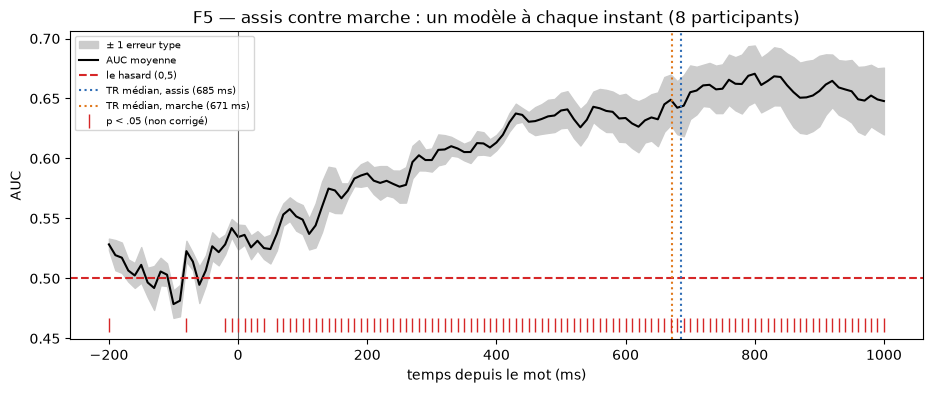

In [14]:
# ---- F5 : l'AUC du groupe dans le temps ------------------------------------------------------------------------------------------
moyenne = auc.mean(axis=1)
erreur = auc.std(axis=1, ddof=1) / np.sqrt(auc.shape[1])
t_dec, p_dec = stats.ttest_1samp(auc.to_numpy(), 0.5, axis=1)   # un test contre 0,5 à chaque instant (non corrigé)
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(temps_dec * 1000, moyenne - erreur, moyenne + erreur, color='0.8', label='± 1 erreur type')
ax.plot(temps_dec * 1000, moyenne, color='k', label='AUC moyenne')
ax.axhline(0.5, color='C3', ls='--', label='le hasard (0,5)')
ax.axvline(0, color='0.4', lw=0.8)                           # l'apparition du mot
for classe, couleur in ((CLASSE_A, '#2f6db5'), (CLASSE_B, '#e0791d')):   # le temps de réaction médian de chaque classe
    tr = attributs.loc[attributs[COLONNE] == classe, 'tr_ms'].median()
    ax.axvline(tr, color=couleur, ls=':', lw=1.5, label=f'TR médian, {classe} ({tr:.0f} ms)')
significatif = p_dec < 0.05
ax.plot(temps_dec[significatif] * 1000, np.full(significatif.sum(), ax.get_ylim()[0] + 0.005), '|', color='C3', ms=10,
        label='p < .05 (non corrigé)')
ax.set_xlabel('temps depuis le mot (ms)')
ax.set_ylabel('AUC')
ax.set_title(f'F5 — {CLASSE_A} contre {CLASSE_B} : un modèle à chaque instant ({auc.shape[1]} participants)')
ax.legend(fontsize=7, loc='upper left')
plt.show()

**Que regarder ? (F5)** Avec la posture, l'AUC est proche de 0,5 avant le mot : la ligne de base (de -200 à 0 ms) met chaque essai à zéro
et efface les différences. Elle monte ensuite jusqu'à 0,67 vers 800 ms.

Avec `CIBLE = 'lexicalite'`, l'AUC dépasse 0,5 à partir d'environ 280 ms, la période de la N400, avant la plupart des réponses ; elle
atteint 0,57 vers 450 ms, puis de nouveau après les réponses. Après le TR médian, une partie de l'information peut venir de la réponse
elle-même : les pseudo-mots reçoivent leur réponse environ 100 ms plus tard (les pointillés), et l'activité liée à la tape n'arrive pas au
même moment. Avec `'frequence'`, la courbe reste proche de 0,5 ; elle atteint 0,54 après le mot, mais aussi avant lui, où cela ne peut être que le
hasard. Les traits rouges ne sont pas corrigés pour les 121 instants testés.

## 5. Mieux que le hasard ? Le test de permutation (Bloc Type 2)

Avec peu d'essais, un modèle peut dépasser 0,5 par hasard (Combrisson et Jerbi, 2015). Pour savoir ce que le hasard donne avec *ces*
essais, on mélange les étiquettes (on attribue au hasard les classes aux essais), on refait toute la validation croisée, et on recommence
des centaines de fois. On obtient la distribution des précisions quand il n'y a rien à apprendre. Le p est la part de ces précisions qui
égalent ou dépassent la vraie.

La section 2 teste le groupe (un t contre 0,5, sur les participants) ; ce test-ci porte sur un seul participant.

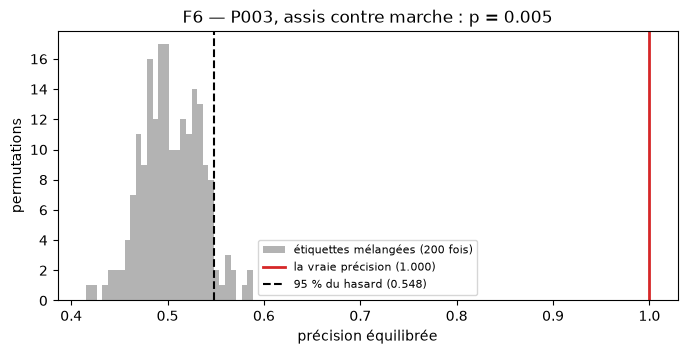

In [15]:
# ---- 5.1 Le test de permutation pour votre participant ---------------------------------------------------------------------------
N_PERMUTATIONS = 200         # modifiable : plus de permutations donnent un p plus précis, mais prennent plus de temps
t = essais_de(PARTICIPANT_EXEMPLE)
y = (t[COLONNE] == CLASSE_B).to_numpy(int)
vrai, hasard, p_perm = permutation_test_score(nouveau_modele(), t[COLONNES[ATTRIBUTS]].to_numpy(), y, cv=plis, scoring='balanced_accuracy',
                                              n_permutations=N_PERMUTATIONS, random_state=GRAINE)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(hasard, bins=30, color='0.7', label=f'étiquettes mélangées ({N_PERMUTATIONS} fois)')
ax.axvline(vrai, color='C3', lw=2, label=f'la vraie précision ({vrai:.3f})')
ax.axvline(np.percentile(hasard, 95), color='k', ls='--', label=f'95 % du hasard ({np.percentile(hasard, 95):.3f})')
ax.set_xlabel('précision équilibrée')
ax.set_ylabel('permutations')
ax.set_title(f'F6 — {PARTICIPANT_EXEMPLE}, {CLASSE_A} contre {CLASSE_B} : p = {p_perm:.3f}')
ax.legend(fontsize=8)
plt.show()
bilan[f'F6 {CIBLE} ({ATTRIBUTS}), {PARTICIPANT_EXEMPLE} : permutation'] = dict(n=len(y), moyenne=round(vrai, 3), p=round(p_perm, 4))

**Que regarder ? (F6)** Avec la posture, la vraie précision de P003 (1,00) dépasse toutes celles obtenues avec des étiquettes mélangées :
p = .005, le plus petit p possible avec 200 permutations (1 / 201). Avec `CIBLE = 'lexicalite'`, P003 obtient 0,535, à l'intérieur de la
distribution du hasard (p = .149) : pour lui seul, on ne peut pas dire que le modèle fait mieux que le hasard, alors que le groupe le fait
(section 2). Regardez aussi la largeur de cette distribution : avec quelques centaines d'essais, une précision de 0,53 ou 0,54 arrive par
hasard (Combrisson et Jerbi, 2015).

## 6. Généraliser à une nouvelle personne (Bloc Type 2)

Jusqu'ici, chaque modèle était entraîné et testé sur le même participant. Un modèle utile en pratique devrait reconnaître la condition chez
quelqu'un qu'il n'a jamais vu. La validation **« un participant de côté »** (*leave-one-subject-out*) entraîne sur tous les participants
sauf un, teste sur celui-là, et recommence pour chacun (Varoquaux et al., 2017). C'est plus difficile : les signaux diffèrent d'une personne
à l'autre (la forme de la tête, le contact des électrodes, le niveau de bruit).

Nouvelle personne : précision moyenne 0.840 (contre 0,5 : t(7) = 9.79, p = 0.0000)


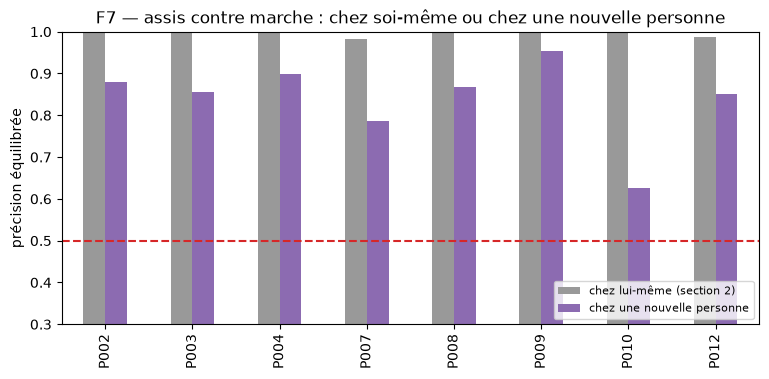

In [16]:
# ---- 6.1 Entraîner sur les autres, tester sur un participant ---------------------------------------------------------------------
toutes = pd.concat([essais_de(p) for p in resultats.index], ignore_index=True)   # les essais de tous les participants de la section 2
y = (toutes[COLONNE] == CLASSE_B).to_numpy(int)
scores = cross_val_score(nouveau_modele(), toutes[COLONNES[ATTRIBUTS]].to_numpy(), y, groups=toutes['participant'],
                         cv=LeaveOneGroupOut(), scoring='balanced_accuracy')   # un pli par participant laissé de côté
nouvelle = pd.DataFrame({'chez lui-même (section 2)': resultats['précision équilibrée'],
                         'chez une nouvelle personne': pd.Series(scores, index=sorted(toutes['participant'].unique()))})
t_n, p_n = stats.ttest_1samp(nouvelle['chez une nouvelle personne'], 0.5)
print(f'Nouvelle personne : précision moyenne {scores.mean():.3f} (contre 0,5 : t({len(scores) - 1}) = {t_n:.2f}, p = {p_n:.4f})')
bilan[f'6.1 {CIBLE} ({ATTRIBUTS}) : nouvelle personne contre 0,5'] = dict(n=len(scores), moyenne=round(scores.mean(), 3), t=round(t_n, 2),
                                                                          p=round(p_n, 4))
fig, ax = plt.subplots(figsize=(9, 3.8))
nouvelle.plot.bar(ax=ax, color=['0.6', '#8c6bb1'])
ax.axhline(0.5, color='C3', ls='--')
ax.set_ylim(0.3, 1.0)
ax.set_ylabel('précision équilibrée')
ax.set_title(f'F7 — {CLASSE_A} contre {CLASSE_B} : chez soi-même ou chez une nouvelle personne')
ax.legend(fontsize=8, loc='lower right')
plt.show()

**Que regarder ? (F7)** Avec la posture, un modèle entraîné sur les autres reconnaît encore la posture d'une nouvelle personne (0,84 en
moyenne), mais moins bien que chez elle-même, et de façon très variable : de 0,63 (P010) à 0,96 (P009). Le bruit de la marche n'a pas la
même force chez tout le monde. Avec `CIBLE = 'lexicalite'`, la précision chez une nouvelle personne tombe au hasard (0,50) : les
différences entre mots et pseudo-mots sont trop petites, et trop différentes d'une personne à l'autre, pour se transférer.

## 7. D'autres modèles (Bloc Type 3)

La régression logistique est un modèle **linéaire** : elle sépare les classes par une frontière droite dans l'espace des attributs. On peut
essayer d'autres modèles : l'analyse discriminante linéaire avec régularisation (LDA, très utilisée en EEG), une machine à vecteurs de
support linéaire (SVM), et une forêt aléatoire (*random forest*, non linéaire). La cellule compare leur précision équilibrée, avec les mêmes
plis, chez chaque participant.

In [17]:
# ---- 7.1 Quatre modèles, les mêmes plis ------------------------------------------------------------------------------------------
modeles = {'régression logistique': lambda: nouveau_modele(),
           'LDA régularisée': lambda: make_pipeline(SimpleImputer(), StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
           'SVM linéaire': lambda: make_pipeline(SimpleImputer(), StandardScaler(), SVC(kernel='linear', class_weight='balanced')),
           'forêt aléatoire': lambda: make_pipeline(SimpleImputer(), RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                                                         random_state=GRAINE))}   # SimpleImputer : comme en 1.2
lignes = []
for participant in resultats.index:
    t = essais_de(participant)
    y = (t[COLONNE] == CLASSE_B).to_numpy(int)
    ligne = {'participant': participant}
    for nom, fabrique in modeles.items():
        ligne[nom] = cross_val_score(fabrique(), t[COLONNES[ATTRIBUTS]].to_numpy(), y, cv=plis, scoring='balanced_accuracy').mean()
    lignes.append(ligne)
par_modele = pd.DataFrame(lignes).set_index('participant')
print(par_modele.mean().round(3).to_string())
par_modele.round(3)

régression logistique    0.996
LDA régularisée          0.998
SVM linéaire             0.995
forêt aléatoire          0.997


,régression logistique,LDA régularisée,SVM linéaire,forêt aléatoire
participant,,,,
P002,0.996,0.998,0.996,0.997
P003,1.000,0.998,1.000,1.000
P004,1.000,1.000,1.000,1.000
P007,0.983,0.993,0.972,0.998
P008,1.000,1.000,1.000,1.000
P009,1.000,0.997,1.000,1.000
P010,0.999,1.000,0.999,1.000
P012,0.987,0.996,0.989,0.983


**Que regarder ? (7.1)** Les quatre modèles donnent presque la même précision : de 0,995 à 0,998 pour la posture ; pour le mot contre le
pseudo-mot, 0,57 pour les trois modèles linéaires et 0,55 pour la forêt aléatoire. Avec quelques centaines d'essais bruités, un modèle plus
complexe n'aide pas : ce sont les données qui limitent, pas le modèle.

**Bloc Type 3.** Changez la régularisation de la régression logistique (par exemple `LogisticRegression(C=0.01, ...)` dans
`nouveau_modele`, cellule 1.2), ou gardez moins d'attributs (par exemple les seules électrodes centrales) : la précision change-t-elle ?

## 8. Synthèse (Bloc Type 1)

Le tableau réunit les tests faits avec vos derniers choix. Relancez le notebook avec les autres cibles pour compléter votre tableau.

In [18]:
# ---- 8.1 Tous vos tests ----------------------------------------------------------------------------------------------------------
print(f'Cible « {CIBLE} » ({CLASSE_A} contre {CLASSE_B}), attributs : {ATTRIBUTS}')
pd.DataFrame.from_dict(bilan, orient='index')                # une ligne par test

Cible « posture » (assis contre marche), attributs : les deux


,n,moyenne,t,p
"2.1 posture (les deux) : précision contre 0,5",8,0.996,210.00,0.000
"3.1 posture, attributs erp : précision contre 0,5",8,0.664,8.95,0.000
"3.1 posture, attributs bandes : précision contre 0,5",8,0.996,209.24,0.000
"3.1 posture, attributs les deux : précision contre 0,5",8,0.996,210.00,0.000
"F6 posture (les deux), P003 : permutation",550,1.000,NaN,0.005
"6.1 posture (les deux) : nouvelle personne contre 0,5",8,0.840,9.79,0.000


**Pour votre rapport.**
1. Énoncez votre prédiction pour chaque cible *avant* de présenter les résultats.
2. Pour chaque cible, rapportez la précision équilibrée moyenne, le test contre 0,5 (t, ddl, p) et le nombre de participants ; pour un
   participant, le test de permutation.
3. Dites d'où vient l'information (3.1 et F4) et quand elle apparaît (F5).
4. Discutez les limites : un modèle qui réussit peut reconnaître le bruit (la posture) ; une précision au-dessus de 0,5 peut venir du hasard
   (F6) ; ce qui marche chez une personne peut ne pas marcher chez une autre (F7).

<details><summary>Indices</summary>

La posture se reconnaît presque parfaitement, surtout grâce à la puissance des bandes, plus haute en marche à toutes les fréquences et
à toutes les électrodes : c'est le bruit de la marche. Le mot contre le pseudo-mot se reconnaît un peu mieux que le hasard dans le groupe
(0,57), à partir d'environ 280 ms, mais pas chez une nouvelle personne. La fréquence du mot reste au niveau du hasard.
</details>

### Références

- Combrisson, E., & Jerbi, K. (2015). Exceeding chance level by chance: The caveat of theoretical chance levels in brain signal classification and statistical assessment of decoding accuracy. *Journal of Neuroscience Methods, 250*, 126-136. https://doi.org/10.1016/j.jneumeth.2015.01.010
- Grootswagers, T., Wardle, S. G., & Carlson, T. A. (2017). Decoding dynamic brain patterns from evoked responses: A tutorial on multivariate pattern analysis applied to time series neuroimaging data. *Journal of Cognitive Neuroscience, 29*, 677-697. https://doi.org/10.1162/jocn_a_01068
- King, J.-R., & Dehaene, S. (2014). Characterizing the dynamics of mental representations: The temporal generalization method. *Trends in Cognitive Sciences, 18*, 203-210. https://doi.org/10.1016/j.tics.2014.01.002
- Varoquaux, G., Raamana, P. R., Engemann, D. A., Hoyos-Idrobo, A., Schwartz, Y., & Thirion, B. (2017). Assessing and tuning brain decoders: Cross-validation, caveats, and guidelines. *NeuroImage, 145*, 166-179. https://doi.org/10.1016/j.neuroimage.2016.10.038